## Question 1:

In [11]:
import pandas as pd

data = {'Customer_ID': [101, 102, 103, 101, 104, 102, 101, 105, 102, 103],
        'Purchase_Amount': [200, 150, 180, 220, 300, 200, 100, 400, 250, 300]}
df = pd.DataFrame(data)

tot_purchases = df.groupby('Customer_ID',as_index=False)['Purchase_Amount'].sum()
print("Total Purchases per Customer:")
print(tot_purchases)

top_3 = tot_purchases.sort_values(by='Purchase_Amount',ascending=False).head(3)

print("Top 3 Frequent Customers:")
print(top_3)


Total Purchases per Customer:
   Customer_ID  Purchase_Amount
0          101              520
1          102              600
2          103              480
3          104              300
4          105              400
Top 3 Frequent Customers:
   Customer_ID  Purchase_Amount
1          102              600
0          101              520
2          103              480


## Question 2:

In [33]:
import pandas as pd
import numpy as np

data = {'Day': range(1, 31),
        'Sales': [25, 30, 28, 45, 55, 60, 22, 80, 95, 120,
                  33, 29, 27, 35, 40, 50, 85, 110, 105, 92,
                  30, 34, 31, 33, 36, 42, 44, 48, 90, 200]}
df = pd.DataFrame(data)
df

,Day,Sales
0,1,25
1,2,30
2,3,28
3,4,45
4,5,55
5,6,60
6,7,22
7,8,80
8,9,95
9,10,120


In [34]:
Q1 = np.percentile(df['Sales'],25)
Q3 = np.percentile(df['Sales'],75)
IQR = Q3 - Q1
print("Q1 =",Q1, "Q3 =",Q3, "IQR =",IQR)

Q1 = 31.5 Q3 = 83.75 IQR = 52.25


In [39]:
#Check for outliers
LB = Q1 - (1.5 * IQR)
UB = Q3 + (1.5 * IQR)

LB, UB

outliers = df[(df['Sales'] < LB) | (df['Sales'] > UB)]
print("Outliers detected:")
print(outliers)

Outliers detected:
    Day  Sales
29   30    200


In [45]:
median_Sales = df['Sales'].median()
df['Sales'] = np.where((df['Sales'] < LB) | (df['Sales'] > UB), median_Sales, df['Sales'])
print("After removing outliers: ")
df

After removing outliers: 


,Day,Sales
0,1,25.0
1,2,30.0
2,3,28.0
3,4,45.0
4,5,55.0
5,6,60.0
6,7,22.0
7,8,80.0
8,9,95.0
9,10,120.0


## Question 3:

In [47]:
import pandas as pd

data = {'Group': ['Treatment']*10 + ['Control']*10,
        'Blood_Pressure': [120, 115, 118, 123, 122, 119, 124, 117, 116, 121,
                            130, 135, 140, 138, 142, 136, 139, 134, 137, 141]}

df = pd.DataFrame(data)
df


,Group,Blood_Pressure
0,Treatment,120
1,Treatment,115
2,Treatment,118
3,Treatment,123
4,Treatment,122
5,Treatment,119
6,Treatment,124
7,Treatment,117
8,Treatment,116
9,Treatment,121


In [52]:
from scipy import stats
BP_treatment = df[df['Group']=='Treatment']['Blood_Pressure']
BP_Control = df[df['Group']=='Control']['Blood_Pressure']

results = stats.ttest_ind(BP_treatment,BP_Control)

print(f"Statistics: {results.statistic}")
print(f"P-Value: {results.pvalue}")

if (results.pvalue < 0.05):
    print("Reject the Null Hypothesis: The drug has a significant effect.")
else:
     print("Fail to Reject the Null Hypothesis: The drug has no significant effect.")


Statistics: -11.870553692962728
P-Value: 6.008066605173374e-10
Reject the Null Hypothesis: The drug has a significant effect.


## Question 4:

In [60]:
import pandas as pd
data = {"Region": ["North", "South", "East", "West", "Central"],
        "TV_Ad_Budget": [200,300, 400, 500, 600],
        "Social_Media_Budget": [150,250, 300, 450, 500],
        "Sales": [20,35, 50, 60, 80]
}

df = pd.DataFrame(data)
df

,Region,TV_Ad_Budget,Social_Media_Budget,Sales
0,North,200,150,20
1,South,300,250,35
2,East,400,300,50
3,West,500,450,60
4,Central,600,500,80


In [67]:
# Find Convariance
tv_sales_cov = df['TV_Ad_Budget'].cov(df['Sales'])
social_sales_cov = df['Social_Media_Budget'].cov(df['Sales'])

print("Covariance (TV vs Sales) : ", tv_sales_cov)
print("Covariance (Social Media vs Sales): ", social_sales_cov)

tv_sales_cor = df['TV_Ad_Budget'].corr(df['Sales'])
social_sales_cor = df['Social_Media_Budget'].corr(df['Sales'])

print("Correlation (TV vs Sales) : ", tv_sales_cor)
print("Correlation (Social Media vs Sales) : ", social_sales_cor)

if(tv_sales_cor > social_sales_cor):
    print("TV Ads have a stronger impact on Sales.")
else:
    print("Social Media have a stronger impact on Sales.")

               

Covariance (TV vs Sales) :  3625.0
Covariance (Social Media vs Sales):  3225.0
Correlation (TV vs Sales) :  0.9958640886279954
Correlation (Social Media vs Sales) :  0.9724846021568381
TV Ads have a stronger impact on Sales.


## Question 5:


Mean Delivery Time:  65.0625
Standard Deviation of Delivery Time:  41.718504212759115


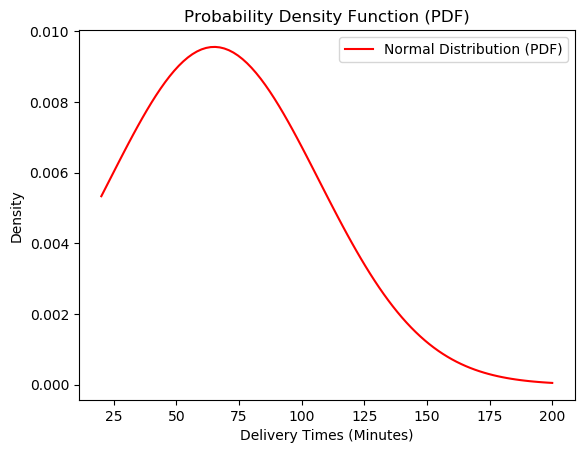

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
del_times = [25, 30, 28, 45, 55, 60, 22, 80, 95, 120, 33, 29, 
                  27, 35, 40, 50, 85, 110, 105, 92, 30, 34, 31, 33, 36, 42, 
                  44, 48, 90, 200, 20, 25, 27, 32, 38, 41, 47, 58, 62, 77, 80, 84, 90, 110, 123, 145, 150, 160]

df = np.array(del_times)
dt_mean = df.mean()
print("Mean Delivery Time: ", dt_mean)
dt_std = df.std()
print("Standard Deviation of Delivery Time: ", dt_std)

#Plot a Graph
x=np.linspace(min(df),max(df),100)
pdf = norm.pdf(x, dt_mean, dt_std)

plt.plot(x,pdf,color="red", Label="Normal Distribution (PDF)")
plt.xlabel("Delivery Times (Minutes)")
plt.ylabel("Density")
plt.title("Probability Density Function (PDF)")
plt.legend(loc="upper right")
plt.show()
